# Managerial Insights from Operational Coordination Strategies

This notebook supports the managerial-insight chapter of the thesis. It compares operational strategies for coordinating rebalancing and maintenance in the shared micromobility system.

The current comparison set contains four strategies: one integrated vehicle, two integrated vehicles, daytime separation with a maintenance window, and temporal separation with after-hours maintenance. Each run folder contains `results.csv` and seed-level `hourly_metrics.csv`, `daily_metrics.csv`, and `decisions.csv` files.

## Primary Data Sources

The default comparison uses these run folders:

- `run_logs/run_20260515_165207`: S1, one integrated VFA-based service vehicle.
- `run_logs/run_20260515_165249`: S2, two integrated VFA-based service vehicles.
- `run_logs/run_20260515_165327`: S3, daytime rebalancing plus a daytime maintenance-window vehicle.
- `run_logs/run_20260515_165446`: S4, daytime rebalancing plus after-hours maintenance.

The loader automatically discovers the `scenario_*` folder inside each run folder and loads all available `seed_*` subfolders.

Expected files inside each scenario folder:

- `results.csv`: one row per seed with final scenario-level outcomes.
- `seed_*/hourly_metrics.csv`: hourly service, breakdown, restoration, and backlog metrics.
- `seed_*/daily_metrics.csv`: daily aggregate outcomes.
- `seed_*/decisions.csv`: decision-level action composition, vehicle state, policy type, and active time window.

In [47]:
from pathlib import Path
import os
import re
import warnings

# Keep Matplotlib cache local to the project when running on restricted machines.
os.environ.setdefault("MPLCONFIGDIR", str(Path.cwd() / ".matplotlib_cache"))
Path(os.environ["MPLCONFIGDIR"]).mkdir(exist_ok=True)

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option("display.max_columns", 160)
pd.set_option("display.width", 180)

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams.update({
    "figure.figsize": (9, 5),
    "axes.spines.top": False,
    "axes.spines.right": False,
})

# Coordination-strategy comparison set. Each path may be a run folder containing
# one or more scenario_* folders, or a single scenario folder.
SCENARIO_RUN_DIRS = [
    Path("run_logs/run_20260515_165207"),  # S1: integrated VFA, 1 vehicle
    Path("run_logs/run_20260515_165249"),  # S2: integrated VFA, 2 vehicles
    Path("run_logs/run_20260515_165327"),  # S3: rebalancing + daytime maintenance window
    Path("run_logs/run_20260515_165446"),  # S4: rebalancing + after-hours maintenance
]

# Set to a scenario name to zoom into one scenario in the detailed sections.
# Keep as None when the notebook is used primarily for strategy comparison.
PRIMARY_SCENARIO_NAME = None

# Add extra run folders here if you later generate more coordination strategies.
OPTIONAL_COMPARISON_RUN_DIRS = []

# Human-readable labels for comparison plots. Keys can be exact scenario names,
# scenario folder names, run folder names, or full path strings.
CONTRAST_LABELS = {
    "S1_integrated_vfa_1": "Integrated VFA, 1 vehicle",
    "scenario_S1_integrated_vfa_1_TD_W34_old_D504h_V1": "Integrated VFA, 1 vehicle",
    "run_20260515_165207": "Integrated VFA, 1 vehicle",
    "S2_integrated_vfa_2": "Integrated VFA, 2 vehicles",
    "scenario_S2_integrated_vfa_2_TD_W34_old_D504h_V2": "Integrated VFA, 2 vehicles",
    "run_20260515_165249": "Integrated VFA, 2 vehicles",
    "S3_day_rebalance_day_maintenance": "Separated: day rebalance + maintenance window",
    "scenario_S3_day_rebalance_day_maintenance_TD_W34_old_D504h_V2": "Separated: day rebalance + maintenance window",
    "run_20260515_165327": "Separated: day rebalance + maintenance window",
    "S4_day_rebalance_after_hours": "Separated: day rebalance + after-hours maintenance",
    "scenario_S4_day_rebalance_after_hours_TD_W34_old_D504h_V2": "Separated: day rebalance + after-hours maintenance",
    "run_20260515_165446": "Separated: day rebalance + after-hours maintenance",
}

CONTRAST_ORDER = [
    "Integrated VFA, 1 vehicle",
    "Integrated VFA, 2 vehicles",
    "Separated: day rebalance + maintenance window",
    "Separated: day rebalance + after-hours maintenance",
]

PEAK_HOURS = [(7, 9), (15, 18)]
OUTPUT_DIR = Path("managerial_insights_figures")
OUTPUT_DIR.mkdir(exist_ok=True)


In [48]:
# Loading utilities

CSV_FILES = {
    "hourly": "hourly_metrics.csv",
    "daily": "daily_metrics.csv",
    "decisions": "decisions.csv",
}


def read_csv_if_exists(path: Path, warn: bool = True) -> pd.DataFrame:
    if not path.exists():
        if warn:
            warnings.warn(f"Missing file: {path}")
        return pd.DataFrame()
    try:
        return pd.read_csv(path)
    except pd.errors.EmptyDataError:
        if warn:
            warnings.warn(f"Empty CSV file: {path}")
        return pd.DataFrame()


def scenario_name_from_folder(run_dir: Path) -> str:
    name = run_dir.name
    if name.startswith("scenario_"):
        name = name[len("scenario_"):]
    # Remove technical suffixes such as _TD_W34_old_D504h_V2 when present.
    name = re.sub(r"_TD_.*$", "", name)
    return name


def default_contrast_label(scenario_name: str, run_dir: Path) -> str:
    readable = {
        "S1_integrated_vfa_1": "Integrated VFA, 1 vehicle",
        "S2_integrated_vfa_2": "Integrated VFA, 2 vehicles",
        "S3_day_rebalance_day_maintenance": "Separated: day rebalance + maintenance window",
        "S4_day_rebalance_after_hours": "Separated: day rebalance + after-hours maintenance",
    }
    if scenario_name in readable:
        return readable[scenario_name]
    if "hybrid_EX15" in run_dir.name:
        return "Integrated hybrid rollout baseline"
    return scenario_name.replace("_", " ")


def make_contrast_label(run_dir: Path, scenario_name: str) -> str:
    candidates = [
        str(run_dir),
        run_dir.name,
        scenario_name,
        str(run_dir.resolve()) if run_dir.exists() else str(run_dir),
    ]
    for key in candidates:
        if key in CONTRAST_LABELS:
            return CONTRAST_LABELS[key]
    return default_contrast_label(scenario_name, run_dir)


def ordered_labels(labels) -> list[str]:
    unique = [label for label in labels if pd.notna(label)]
    unique = list(dict.fromkeys(unique))
    preferred = [label for label in CONTRAST_ORDER if label in unique]
    remaining = sorted(label for label in unique if label not in preferred)
    return preferred + remaining


def is_scenario_folder(path: Path) -> bool:
    return path.exists() and (any(path.glob("seed_*")) or (path / "results.csv").exists())


def normalize_input_path(path: Path) -> Path:
    path = Path(path)
    if path.name.startswith("seed_"):
        return path.parent
    if path.is_file():
        # Allows pasting an explicit CSV file path from the file explorer.
        if path.parent.name.startswith("seed_"):
            return path.parent.parent
        return path.parent
    return path


def discover_scenario_folders(paths) -> list[Path]:
    folders = []
    seen = set()
    for raw_path in paths:
        path = normalize_input_path(Path(raw_path))
        candidates = []
        if is_scenario_folder(path):
            candidates.append(path)
        candidates.extend(sorted(p for p in path.glob("scenario_*") if is_scenario_folder(p)))
        for candidate in candidates:
            resolved = candidate.resolve()
            if resolved not in seen:
                folders.append(candidate)
                seen.add(resolved)
    return folders


def load_scenario_folder(run_dir: Path) -> dict[str, pd.DataFrame]:
    run_dir = normalize_input_path(Path(run_dir))
    scenario_name = scenario_name_from_folder(run_dir)
    contrast_label = make_contrast_label(run_dir, scenario_name)
    config_label = f"{contrast_label} | {run_dir.parent.name}"

    results = read_csv_if_exists(run_dir / "results.csv", warn=False)
    if not results.empty:
        if "scenario_name" in results.columns and results["scenario_name"].notna().any():
            scenario_name = str(results["scenario_name"].dropna().iloc[0])
            contrast_label = make_contrast_label(run_dir, scenario_name)
            config_label = f"{contrast_label} | {run_dir.parent.name}"
        results["source_file"] = str(run_dir / "results.csv")
        results["scenario_folder"] = str(run_dir)
        if "scenario_name" not in results.columns:
            results["scenario_name"] = scenario_name
        else:
            results["scenario_name"] = results["scenario_name"].fillna(scenario_name)
        results["policy_label"] = config_label
        results["contrast_label"] = contrast_label
        if "policy_name" not in results.columns:
            results["policy_name"] = results.get("exp_name", scenario_name)

    frames = {kind: [] for kind in CSV_FILES}
    for seed_dir in sorted(run_dir.glob("seed_*")):
        seed_match = re.search(r"seed_(\d+)", seed_dir.name)
        seed_value = int(seed_match.group(1)) if seed_match else np.nan
        for kind, filename in CSV_FILES.items():
            csv_path = seed_dir / filename
            df = read_csv_if_exists(csv_path, warn=False)
            if df.empty:
                continue
            if "seed" not in df.columns:
                df["seed"] = seed_value
            if "scenario_name" not in df.columns:
                df["scenario_name"] = scenario_name
            df["source_file"] = str(csv_path)
            df["scenario_folder"] = str(run_dir)
            df["policy_label"] = config_label
            df["contrast_label"] = contrast_label
            frames[kind].append(df)

    return {
        "results": results,
        "hourly": pd.concat(frames["hourly"], ignore_index=True, sort=False) if frames["hourly"] else pd.DataFrame(),
        "daily": pd.concat(frames["daily"], ignore_index=True, sort=False) if frames["daily"] else pd.DataFrame(),
        "decisions": pd.concat(frames["decisions"], ignore_index=True, sort=False) if frames["decisions"] else pd.DataFrame(),
    }


def concat_loaded(loaded, kind: str) -> pd.DataFrame:
    frames = [item[kind] for item in loaded if not item[kind].empty]
    return pd.concat(frames, ignore_index=True, sort=False) if frames else pd.DataFrame()


def load_scenario_paths(paths) -> dict[str, pd.DataFrame]:
    folders = discover_scenario_folders(paths)
    if not folders:
        warnings.warn("No scenario folders were found. Check SCENARIO_RUN_DIRS and OPTIONAL_COMPARISON_RUN_DIRS.")
    loaded = [load_scenario_folder(folder) for folder in folders]
    print("Discovered scenario folders:")
    for folder in folders:
        print(f"- {folder}")
    return {kind: concat_loaded(loaded, kind) for kind in ["results", "hourly", "daily", "decisions"]}


primary_loaded = load_scenario_paths(SCENARIO_RUN_DIRS)
comparison_loaded = load_scenario_paths(OPTIONAL_COMPARISON_RUN_DIRS) if OPTIONAL_COMPARISON_RUN_DIRS else {
    "results": pd.DataFrame(), "hourly": pd.DataFrame(), "daily": pd.DataFrame(), "decisions": pd.DataFrame()
}

results_all = pd.concat([df for df in [primary_loaded["results"], comparison_loaded["results"]] if not df.empty], ignore_index=True, sort=False) if (not primary_loaded["results"].empty or not comparison_loaded["results"].empty) else pd.DataFrame()
hourly_all = pd.concat([df for df in [primary_loaded["hourly"], comparison_loaded["hourly"]] if not df.empty], ignore_index=True, sort=False) if (not primary_loaded["hourly"].empty or not comparison_loaded["hourly"].empty) else pd.DataFrame()
daily_all = pd.concat([df for df in [primary_loaded["daily"], comparison_loaded["daily"]] if not df.empty], ignore_index=True, sort=False) if (not primary_loaded["daily"].empty or not comparison_loaded["daily"].empty) else pd.DataFrame()
decisions_all = pd.concat([df for df in [primary_loaded["decisions"], comparison_loaded["decisions"]] if not df.empty], ignore_index=True, sort=False) if (not primary_loaded["decisions"].empty or not comparison_loaded["decisions"].empty) else pd.DataFrame()


def select_primary(df: pd.DataFrame) -> pd.DataFrame:
    if df.empty or PRIMARY_SCENARIO_NAME is None or "scenario_name" not in df.columns:
        return df.copy()
    selected = df[df["scenario_name"].astype(str).eq(PRIMARY_SCENARIO_NAME)].copy()
    return selected if not selected.empty else df.copy()


results = select_primary(results_all)
hourly = select_primary(hourly_all)
daily = select_primary(daily_all)
decisions = select_primary(decisions_all)

for name, df in {
    "results_all": results_all,
    "hourly_all": hourly_all,
    "daily_all": daily_all,
    "decisions_all": decisions_all,
    "selected_results": results,
    "selected_hourly": hourly,
    "selected_daily": daily,
    "selected_decisions": decisions,
}.items():
    print(f"{name:18s}: {df.shape[0]:>8,} rows, {df.shape[1]:>3} columns")


Discovered scenario folders:
- run_logs/run_20260515_165207/scenario_S1_integrated_vfa_1_TD_W34_old_D504h_V1
- run_logs/run_20260515_165249/scenario_S2_integrated_vfa_2_TD_W34_old_D504h_V2
- run_logs/run_20260515_165327/scenario_S3_day_rebalance_day_maintenance_TD_W34_old_D504h_V2
- run_logs/run_20260515_165446/scenario_S4_day_rebalance_after_hours_TD_W34_old_D504h_V2
results_all       :       40 rows,  39 columns
hourly_all        :   20,200 rows,  37 columns
daily_all         :      880 rows,  26 columns
decisions_all     :  118,427 rows, 102 columns
selected_results  :       40 rows,  39 columns
selected_hourly   :   20,200 rows,  37 columns
selected_daily    :      880 rows,  26 columns
selected_decisions:  118,427 rows, 102 columns


In [49]:
# Cleaning and derived variables

def numeric(df, cols):
    df = df.copy()
    for col in cols:
        if col in df.columns:
            df[col] = pd.to_numeric(df[col], errors="coerce")
    return df


def as_bool(series, default=False):
    if not isinstance(series, pd.Series):
        return pd.Series(default)
    return series.fillna(default).astype(str).str.lower().isin(["true", "1", "yes", "y"])


def add_time_features(df):
    df = df.copy()
    if "hour" in df.columns:
        df["hour"] = pd.to_numeric(df["hour"], errors="coerce") % 24
    if "day" in df.columns:
        df["day"] = pd.to_numeric(df["day"], errors="coerce")
    if {"day", "hour"}.issubset(df.columns):
        df["absolute_hour"] = df["day"] * 24 + df["hour"]
    if {"day", "hour", "minute"}.issubset(df.columns):
        df["time_min"] = df["day"] * 24 * 60 + df["hour"] * 60 + pd.to_numeric(df["minute"], errors="coerce")
    return df


def is_peak_hour(hour):
    if pd.isna(hour):
        return False
    hour = int(hour)
    return any(start <= hour < end for start, end in PEAK_HOURS)


def add_service_metrics(df, prefix=""):
    df = numeric(df, [
        "service_level", "starvations", "congestions", "total_trips",
        "daily_starvations", "daily_congestions", "daily_trips",
    ])
    if {"starvations", "congestions", "total_trips"}.issubset(df.columns):
        failures = df["starvations"].fillna(0) + df["congestions"].fillna(0)
        df["computed_service_level"] = 1 - failures / df["total_trips"].replace(0, np.nan)
    if {"daily_starvations", "daily_congestions", "daily_trips"}.issubset(df.columns):
        failures = df["daily_starvations"].fillna(0) + df["daily_congestions"].fillna(0)
        df["daily_service_level"] = 1 - failures / df["daily_trips"].replace(0, np.nan)
    return df


def add_action_metrics(df):
    df = numeric(df, [
        "functional_pickups", "functional_deliveries", "onsite_repairs", "depot_pickups",
        "depot_deliveries", "load_from_queue", "action_duration_min", "travel_time_min",
        "functional_load_before", "depot_load_before", "total_load_before",
        "functional_load_after", "depot_load_after", "total_load_after",
        "num_rebalancing_actions", "num_maintenance_actions", "num_depot_trips", "vehicle_time_min",
        "vehicle_capacity",
    ])
    has_logged_rebalancing = "num_rebalancing_actions" in df.columns
    has_logged_maintenance = "num_maintenance_actions" in df.columns
    has_logged_depot_trips = "num_depot_trips" in df.columns
    for col in [
        "functional_pickups", "functional_deliveries", "onsite_repairs", "depot_pickups",
        "depot_deliveries", "load_from_queue", "num_rebalancing_actions", "num_maintenance_actions", "num_depot_trips",
    ]:
        if col not in df.columns:
            df[col] = 0

    is_at_depot = as_bool(df.get("is_at_depot", pd.Series(False, index=df.index)))
    next_is_depot = df.get("next_station_id", pd.Series("", index=df.index)).astype(str).str.startswith("D")
    selected_maintenance = as_bool(df.get("selected_action_is_maintenance", pd.Series(False, index=df.index)))
    if "vehicle_active" in df.columns:
        vehicle_active = as_bool(df["vehicle_active"], default=True)
    else:
        vehicle_active = pd.Series(True, index=df.index)

    fallback_maintenance = (
        selected_maintenance
        | (df["onsite_repairs"] > 0)
        | (df["depot_pickups"] > 0)
        | (df["depot_deliveries"] > 0)
        | (df["load_from_queue"] > 0)
    )
    fallback_rebalancing = (df["functional_pickups"] > 0) | (df["functional_deliveries"] > 0)
    fallback_depot_trip = next_is_depot & ~is_at_depot

    df["is_at_depot_bool"] = is_at_depot
    df["next_is_depot"] = next_is_depot
    df["vehicle_active_bool"] = vehicle_active
    df["depot_return_decision"] = np.where(df["num_depot_trips"].notna(), df["num_depot_trips"] > 0, fallback_depot_trip) if has_logged_depot_trips else fallback_depot_trip
    df["maintenance_action"] = np.where(df["num_maintenance_actions"].notna(), df["num_maintenance_actions"] > 0, fallback_maintenance) if has_logged_maintenance else fallback_maintenance
    df["rebalancing_action"] = np.where(df["num_rebalancing_actions"].notna(), df["num_rebalancing_actions"] > 0, fallback_rebalancing) if has_logged_rebalancing else fallback_rebalancing

    # Inactive records are useful diagnostics, but they should not count as operational choices.
    df["depot_return_decision"] = df["depot_return_decision"] & vehicle_active
    df["maintenance_action"] = df["maintenance_action"] & vehicle_active
    df["rebalancing_action"] = df["rebalancing_action"] & vehicle_active
    df["mixed_action"] = df["maintenance_action"] & df["rebalancing_action"]
    df["period"] = np.where(df.get("hour", pd.Series(np.nan, index=df.index)).apply(is_peak_hour), "Peak", "Off-peak")

    # Keep one schema across older integrated logs and newer scenario logs.
    if "vehicle_id" not in df.columns:
        df["vehicle_id"] = "V0"
    else:
        df["vehicle_id"] = df["vehicle_id"].fillna("V0")
    if "vehicle_role" not in df.columns:
        df["vehicle_role"] = "integrated"
    else:
        df["vehicle_role"] = df["vehicle_role"].fillna("integrated")
    if "vehicle_policy_type" not in df.columns:
        df["vehicle_policy_type"] = "policy"
    else:
        df["vehicle_policy_type"] = df["vehicle_policy_type"].fillna("policy")
    if "active_time_window" not in df.columns:
        df["active_time_window"] = "all"
    else:
        df["active_time_window"] = df["active_time_window"].fillna("all")

    df["action_mix_category"] = np.select(
        [
            df["maintenance_action"] & df["rebalancing_action"],
            df["maintenance_action"] & ~df["rebalancing_action"],
            ~df["maintenance_action"] & df["rebalancing_action"],
        ],
        [
            "Mixed rebalancing + maintenance",
            "Pure maintenance",
            "Pure rebalancing",
        ],
        default="Other active decision",
    )

    conditions = [
        ~vehicle_active,
        df["depot_return_decision"],
        is_at_depot & ((df["depot_deliveries"] > 0) | (df["load_from_queue"] > 0)),
        df["mixed_action"],
        df["onsite_repairs"] > 0,
        df["depot_pickups"] > 0,
        df["rebalancing_action"],
        is_at_depot,
    ]
    labels = ["inactive", "go_to_depot", "depot_service", "mixed", "onsite_repair", "depot_collection", "rebalancing", "depot_passthrough"]
    fallback_type = np.select(conditions, labels, default="no_operation")
    if "action_type" in df.columns:
        logged_type = df["action_type"].replace("", np.nan)
        df["derived_action_type"] = logged_type.fillna(pd.Series(fallback_type, index=df.index))
    else:
        df["derived_action_type"] = fallback_type

    if "winning_profile_type" in df.columns:
        df["profile_type"] = df["winning_profile_type"].replace("", np.nan).fillna(df["derived_action_type"])
    else:
        df["profile_type"] = df["derived_action_type"]

    if "vehicle_capacity" in df.columns and df["vehicle_capacity"].notna().any():
        df["estimated_vehicle_capacity"] = df["vehicle_capacity"]
    else:
        load_cols = [c for c in ["total_load_before", "total_load_after"] if c in df.columns]
        if load_cols:
            group_cols = [c for c in ["policy_label", "scenario_name", "seed", "vehicle_id"] if c in df.columns]
            df["estimated_vehicle_capacity"] = df.groupby(group_cols, dropna=False)[load_cols].transform("max").max(axis=1) if group_cols else df[load_cols].max(axis=1).max()
        else:
            df["estimated_vehicle_capacity"] = np.nan
    df["broken_load_before"] = df.get("depot_load_before", np.nan)
    df["broken_load_after"] = df.get("depot_load_after", df["broken_load_before"])
    df["broken_load_to_depot"] = np.where(df["depot_return_decision"], df["broken_load_after"], np.nan)
    df["broken_load_utilization_to_depot"] = df["broken_load_to_depot"] / df["estimated_vehicle_capacity"].replace(0, np.nan)
    return df


def clean_all(results_df, hourly_df, daily_df, decisions_df):
    results_clean = add_service_metrics(results_df)
    hourly_clean = add_service_metrics(add_time_features(hourly_df))
    daily_clean = add_service_metrics(add_time_features(daily_df))
    decisions_clean = add_action_metrics(add_time_features(decisions_df)) if not decisions_df.empty else decisions_df.copy()

    if not hourly_clean.empty:
        hourly_clean["period"] = np.where(hourly_clean["hour"].apply(is_peak_hour), "Peak", "Off-peak")
        hourly_clean["damaged_fraction_total"] = hourly_clean.get("damaged_fraction_onsite", 0).fillna(0) + hourly_clean.get("damaged_fraction_depot", 0).fillna(0)
    if not daily_clean.empty:
        daily_clean["eod_damaged_fraction_total"] = daily_clean.get("eod_damaged_fraction_onsite", 0).fillna(0) + daily_clean.get("eod_damaged_fraction_depot", 0).fillna(0)
    return results_clean, hourly_clean, daily_clean, decisions_clean


results_all, hourly_all, daily_all, decisions_all = clean_all(results_all, hourly_all, daily_all, decisions_all)
results, hourly, daily, decisions = clean_all(results, hourly, daily, decisions)
active_decisions = decisions[decisions.get("vehicle_active_bool", pd.Series(True, index=decisions.index))].copy() if not decisions.empty else decisions.copy()
active_decisions_all = decisions_all[decisions_all.get("vehicle_active_bool", pd.Series(True, index=decisions_all.index))].copy() if not decisions_all.empty else decisions_all.copy()

if not decisions.empty:
    print(f"Selected decisions: {len(decisions):,} total rows; {len(active_decisions):,} active operational rows.")
    diagnostic_cols = [
        "scenario_name",
        "vehicle_id",
        "vehicle_role",
        "active_time_window",
        "vehicle_active_bool",
    ]
    fallback_values = {
        "scenario_name": "unknown_scenario",
        "vehicle_id": "V0",
        "vehicle_role": "integrated",
        "active_time_window": "all",
        "vehicle_active_bool": True,
    }
    missing_diagnostic_cols = [col for col in diagnostic_cols if col not in decisions.columns]
    for col in missing_diagnostic_cols:
        decisions[col] = fallback_values[col]
        active_decisions[col] = fallback_values[col]
    if missing_diagnostic_cols:
        print(f"Added fallback columns for older decision logs: {missing_diagnostic_cols}")
    display(decisions.groupby(diagnostic_cols, dropna=False).size().reset_index(name="rows"))


Selected decisions: 118,427 total rows; 49,545 active operational rows.


,scenario_name,vehicle_id,vehicle_role,active_time_window,vehicle_active_bool,rows
0,S1_integrated_vfa_1,V0,integrated,all,True,15333
1,S2_integrated_vfa_2,V0,integrated,all,True,17046
2,S2_integrated_vfa_2,V1,integrated,all,True,17166
3,S3_day_rebalance_day_maintenance,V0,default,6-20,False,17715
4,S3_day_rebalance_day_maintenance,V1,maintenance_both,17-18,False,18866
5,S4_day_rebalance_after_hours,V0,default,6-20,False,20541
6,S4_day_rebalance_after_hours,V1,maintenance_both,20-22,False,11760


In [50]:
# Loaded contrast labels and scenario folders.
# This table is useful for checking that the plots compare the intended configurations.
if not results_all.empty or not decisions_all.empty:
    label_source = results_all if not results_all.empty else decisions_all
    contrast_table = label_source[[c for c in ["contrast_label", "scenario_name", "scenario_folder"] if c in label_source.columns]].drop_duplicates().sort_values("contrast_label")
    print("Loaded configurations for contrast:")
    display(contrast_table)
else:
    print("No configurations loaded yet.")


Loaded configurations for contrast:


,contrast_label,scenario_name,scenario_folder
0,"Integrated VFA, 1 vehicle",S1_integrated_vfa_1,run_logs/run_20260515_165207/scenario_S1_integ...
10,"Integrated VFA, 2 vehicles",S2_integrated_vfa_2,run_logs/run_20260515_165249/scenario_S2_integ...
30,Separated: day rebalance + after-hours mainten...,S4_day_rebalance_after_hours,run_logs/run_20260515_165446/scenario_S4_day_r...
20,Separated: day rebalance + maintenance window,S3_day_rebalance_day_maintenance,run_logs/run_20260515_165327/scenario_S3_day_r...


In [51]:
# Plot and summary helpers

def mean_ci(df, group_cols, value_col):
    if df.empty or value_col not in df.columns:
        return pd.DataFrame()
    out = df.dropna(subset=[value_col]).groupby(group_cols, dropna=False)[value_col].agg(mean="mean", std="std", n="count").reset_index()
    out["se"] = out["std"] / np.sqrt(out["n"].clip(lower=1))
    out["ci95"] = 1.96 * out["se"]
    return out


def add_ci_errorbar(ax, x, y, yerr, **kwargs):
    ax.errorbar(x, y, yerr=yerr, marker="o", capsize=4, **kwargs)


def savefig(name):
    path = OUTPUT_DIR / name
    plt.savefig(path, dpi=300, bbox_inches="tight")
    print(f"Saved {path}")


def show_required(message):
    print(f"Additional simulation output required: {message}")

## Scenario Run Overview

This section summarizes the selected scenario before moving into the managerial topics. If `PRIMARY_SCENARIO_NAME` is set, the detailed plots use only that scenario. The later comparison section uses all loaded scenarios and optional comparison folders.

,mean,std,min,max
service_level,0.9374,0.0295,0.8915,0.9799
starvations,2843.0500,1446.0442,904.0000,5291.0000
congestions,885.2500,380.1763,244.0000,1678.0000
total_trips,59565.0000,393.0663,58938.0000,60282.0000
total_fixed_on_site,133.6750,99.1485,0.0000,263.0000
total_picked_up_to_depot,130.0750,103.1562,0.0000,240.0000
total_depot_visits,614.5250,558.6653,41.0000,1197.0000
total_functional_pickups,8771.5000,2775.8973,6729.0000,13710.0000
total_functional_deliveries,8907.9250,2830.7911,6736.0000,13931.0000
broken_ratio_end_onsite,0.1121,0.1220,0.0000,0.2924


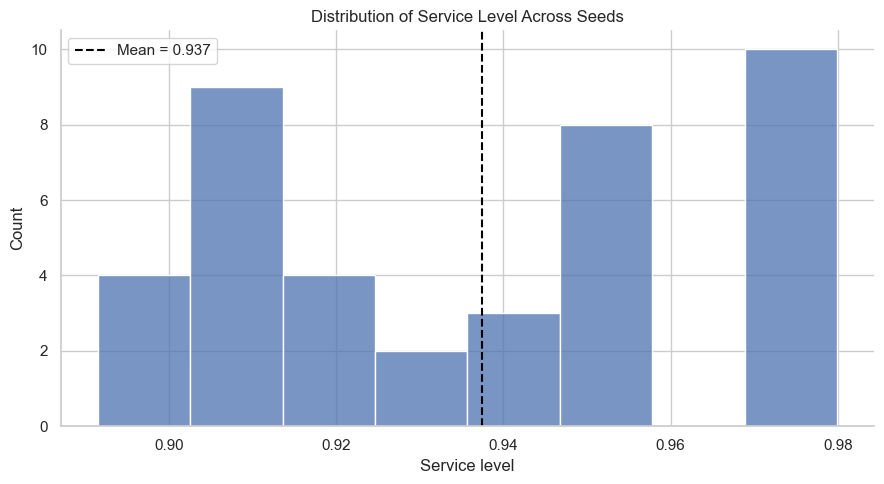

In [52]:
# Final outcome summary across seeds.
if not results.empty:
    outcome_cols = [
        "service_level", "starvations", "congestions", "total_trips",
        "total_fixed_on_site", "total_picked_up_to_depot", "total_depot_visits",
        "total_functional_pickups", "total_functional_deliveries",
        "broken_ratio_end_onsite", "broken_ratio_end_depot", "functional_ratio_end",
    ]
    available = [c for c in outcome_cols if c in results.columns]
    summary = results[available].agg(["mean", "std", "min", "max"]).T
    display(summary.round(4))

    fig, ax = plt.subplots()
    sns.histplot(data=results, x="service_level", bins=8, ax=ax)
    ax.axvline(results["service_level"].mean(), color="black", linestyle="--", label=f"Mean = {results['service_level'].mean():.3f}")
    ax.set_title("Distribution of Service Level Across Seeds")
    ax.set_xlabel("Service level")
    ax.legend()
    plt.tight_layout()
else:
    print("No results.csv loaded.")

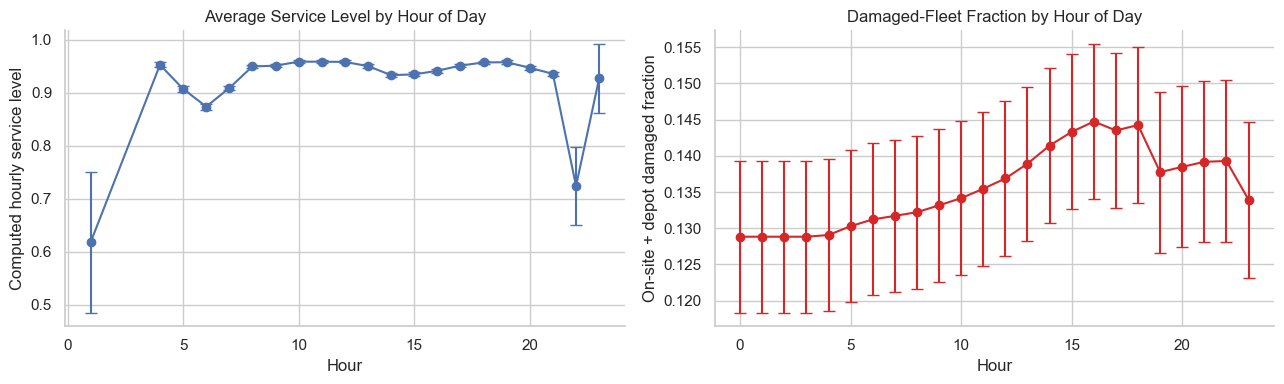

In [53]:
# Hourly system performance over the evaluation horizon.
if not hourly.empty:
    hourly_by_clock = mean_ci(hourly, ["hour"], "computed_service_level")
    damage_by_clock = mean_ci(hourly, ["hour"], "damaged_fraction_total")

    fig, axes = plt.subplots(1, 2, figsize=(13, 4))
    add_ci_errorbar(axes[0], hourly_by_clock["hour"], hourly_by_clock["mean"], hourly_by_clock["ci95"])
    axes[0].set_title("Average Service Level by Hour of Day")
    axes[0].set_xlabel("Hour")
    axes[0].set_ylabel("Computed hourly service level")

    add_ci_errorbar(axes[1], damage_by_clock["hour"], damage_by_clock["mean"], damage_by_clock["ci95"], color="tab:red")
    axes[1].set_title("Damaged-Fleet Fraction by Hour of Day")
    axes[1].set_xlabel("Hour")
    axes[1].set_ylabel("On-site + depot damaged fraction")
    plt.tight_layout()
else:
    print("No hourly_metrics.csv files loaded.")

## 1. Systematic Impact of Decoupled Operations

**Managerial question.** What operational value is gained or lost when rebalancing and maintenance are separated across vehicles or time windows?

For the selected scenario, the first analysis documents how the active vehicles allocate decisions between rebalancing, maintenance, depot trips, and inactive periods. When additional scenarios are added, the comparison section estimates the integration gain by comparing service level, maintenance backlog, and action composition across configurations.

,vehicle_role,vehicle_policy_type,derived_action_type,count,share_within_role
6,integrated,HybridRolloutPolicy,rebalancing,35722,0.721001
3,integrated,HybridRolloutPolicy,no_operation,4441,0.089636
5,integrated,HybridRolloutPolicy,onsite_repair,3471,0.070058
0,integrated,HybridRolloutPolicy,depot_collection,3446,0.069553
1,integrated,HybridRolloutPolicy,depot_service,1271,0.025653
2,integrated,HybridRolloutPolicy,go_to_depot,642,0.012958
4,integrated,HybridRolloutPolicy,onsite_and_depot_collection,552,0.011141


,vehicle_role,vehicle_policy_type,maintenance_share,rebalancing_share,mixed_share,active_decisions
0,integrated,HybridRolloutPolicy,0.1772,0.8599,0.1325,49545


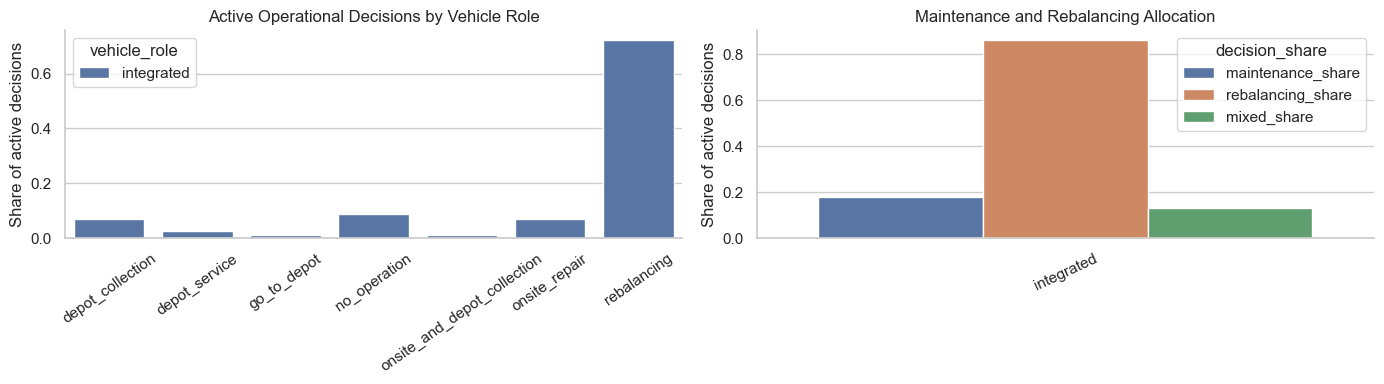

In [54]:
# Action composition of the selected scenario, excluding inactive off-window records.
decision_data = active_decisions
if not decision_data.empty:
    group_cols = [c for c in ["vehicle_role", "vehicle_policy_type", "derived_action_type"] if c in decision_data.columns]
    action_counts = decision_data.groupby(group_cols, dropna=False).size().reset_index(name="count")
    action_counts["share_within_role"] = action_counts["count"] / action_counts.groupby([c for c in ["vehicle_role", "vehicle_policy_type"] if c in action_counts.columns])["count"].transform("sum")
    display(action_counts.sort_values("count", ascending=False))

    fig, axes = plt.subplots(1, 2, figsize=(14, 4))
    sns.barplot(data=action_counts, x="derived_action_type", y="share_within_role", hue="vehicle_role" if "vehicle_role" in action_counts.columns else None, ax=axes[0])
    axes[0].set_title("Active Operational Decisions by Vehicle Role")
    axes[0].set_xlabel("")
    axes[0].set_ylabel("Share of active decisions")
    axes[0].tick_params(axis="x", rotation=35)

    mix_summary = decision_data.groupby([c for c in ["vehicle_role", "vehicle_policy_type"] if c in decision_data.columns], dropna=False).agg(
        maintenance_share=("maintenance_action", "mean"),
        rebalancing_share=("rebalancing_action", "mean"),
        mixed_share=("mixed_action", "mean"),
        active_decisions=("derived_action_type", "size"),
    ).reset_index()
    display(mix_summary.round(4))
    mix_long = mix_summary.melt(id_vars=[c for c in ["vehicle_role", "vehicle_policy_type", "active_decisions"] if c in mix_summary.columns], value_vars=["maintenance_share", "rebalancing_share", "mixed_share"], var_name="decision_share", value_name="share")
    sns.barplot(data=mix_long, x="vehicle_role" if "vehicle_role" in mix_long.columns else "vehicle_policy_type", y="share", hue="decision_share", ax=axes[1])
    axes[1].set_title("Maintenance and Rebalancing Allocation")
    axes[1].set_xlabel("")
    axes[1].set_ylabel("Share of active decisions")
    axes[1].tick_params(axis="x", rotation=25)
    plt.tight_layout()
else:
    print("No active decision rows were loaded. Check vehicle_active and active time windows.")


,vehicle_role,maintenance_opportunity,period,n_decisions,selected_maintenance_share,selected_rebalancing_share
0,integrated,False,Off-peak,25407,0.000000,0.873696
1,integrated,False,Peak,13991,0.000000,0.905296
2,integrated,True,Off-peak,6715,0.875503,0.697990
3,integrated,True,Peak,3432,0.844988,0.890152


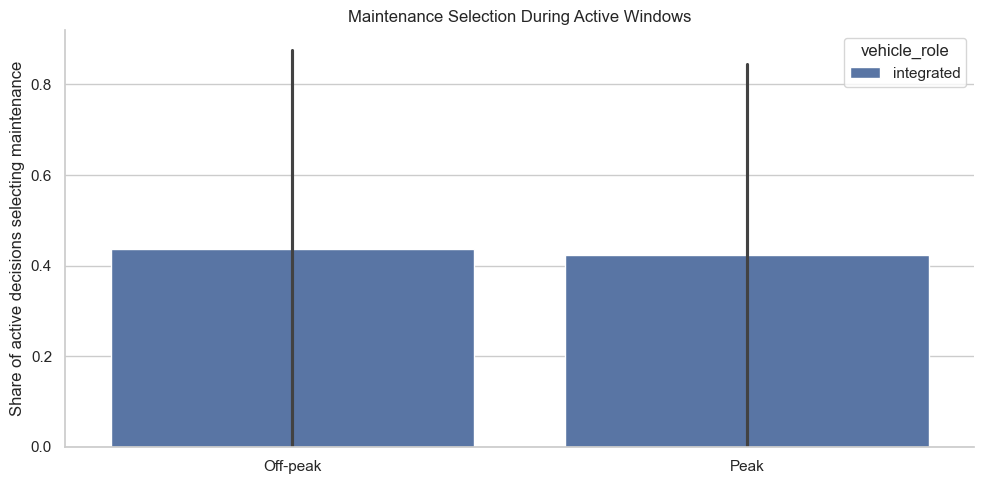

In [55]:
# Maintenance opportunity versus selected maintenance.
decision_data = active_decisions
if not decision_data.empty and "maintenance_flag_present" in decision_data.columns:
    opportunity = decision_data.copy()
    opportunity["maintenance_opportunity"] = opportunity["maintenance_flag_present"].astype(str).str.lower().isin(["true", "1", "yes"])
    group_cols = [c for c in ["vehicle_role", "maintenance_opportunity", "period"] if c in opportunity.columns]
    opp_summary = opportunity.groupby(group_cols, dropna=False).agg(
        n_decisions=("derived_action_type", "size"),
        selected_maintenance_share=("maintenance_action", "mean"),
        selected_rebalancing_share=("rebalancing_action", "mean"),
    ).reset_index()
    display(opp_summary)

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=opp_summary, x="period", y="selected_maintenance_share", hue="vehicle_role" if "vehicle_role" in opp_summary.columns else "maintenance_opportunity", ax=ax)
    ax.set_title("Maintenance Selection During Active Windows")
    ax.set_ylabel("Share of active decisions selecting maintenance")
    ax.set_xlabel("")
    plt.tight_layout()
else:
    show_required("`maintenance_flag_present` in decisions.csv to distinguish maintenance opportunity from selected maintenance.")


**Interpretation.** This evidence shows whether integration is actively used by the policy, not merely allowed by the model. If maintenance, rebalancing, and mixed actions all occur in meaningful shares, the integrated formulation is operationally relevant. A direct integration-gain estimate still requires counterfactual runs where maintenance is restricted to night periods or separated from daytime rebalancing.

**Counterfactual runs needed for causal integration gain.** Re-run the same trained VFA with candidate-set restrictions: night maintenance only, hybrid day/night 1, hybrid day/night 2, and unrestricted integrated. Log the active restriction and the removed candidate types at each decision.

## 2. Temporal Sensitivity Study

**Managerial question.** Does the integrated policy naturally shift maintenance away from peak hours, or does it perform maintenance opportunistically throughout the day?

The single rollout run can answer this behaviorally by comparing peak and off-peak action composition, service levels, and broken-bike accumulation.

,,seed,maintenance_share,rebalancing_share,onsite_repairs,depot_pickups,depot_returns
period,vehicle_role,,,,,,
Off-peak,integrated,46.5,0.1831,0.8370,265.0,277.2,63.3
Peak,integrated,46.5,0.1664,0.9024,178.5,169.8,0.9


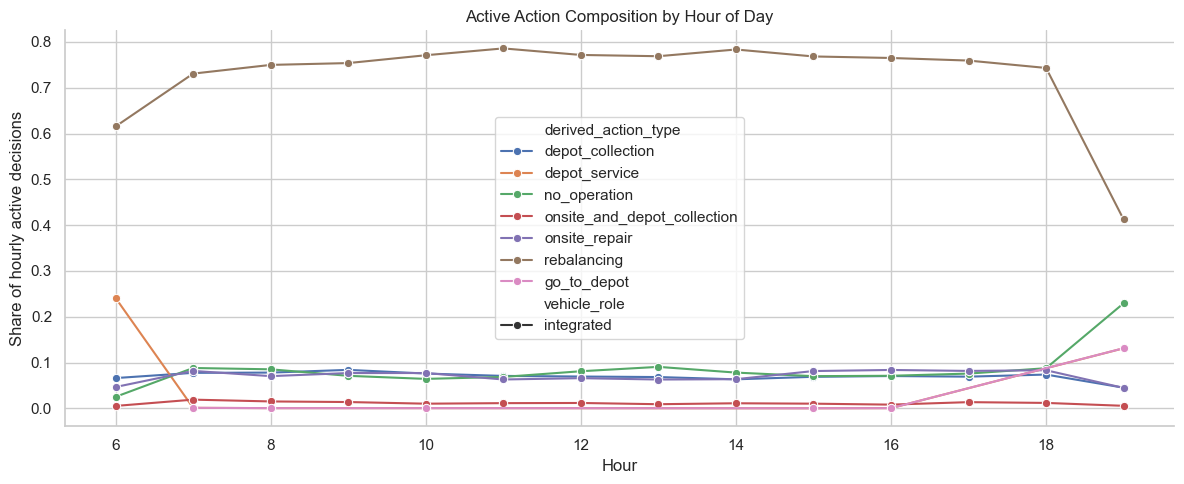

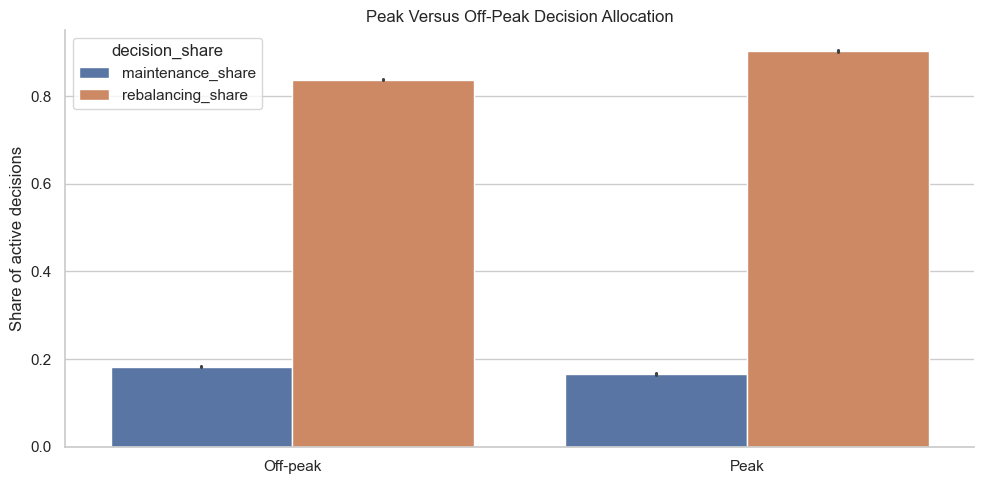

In [56]:
decision_data = active_decisions
if not decision_data.empty:
    hour_action = decision_data.groupby(["hour", "vehicle_role", "derived_action_type"], dropna=False).size().reset_index(name="count")
    hour_total = decision_data.groupby(["hour", "vehicle_role"], dropna=False).size().rename("total").reset_index()
    hour_action = hour_action.merge(hour_total, on=["hour", "vehicle_role"], how="left")
    hour_action["share"] = hour_action["count"] / hour_action["total"]

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.lineplot(data=hour_action, x="hour", y="share", hue="derived_action_type", style="vehicle_role", marker="o", ax=ax)
    ax.set_title("Active Action Composition by Hour of Day")
    ax.set_ylabel("Share of hourly active decisions")
    ax.set_xlabel("Hour")
    plt.tight_layout()

    peak_mix = decision_data.groupby(["period", "vehicle_role", "seed"], dropna=False).agg(
        maintenance_share=("maintenance_action", "mean"),
        rebalancing_share=("rebalancing_action", "mean"),
        onsite_repairs=("onsite_repairs", "sum"),
        depot_pickups=("depot_pickups", "sum"),
        depot_returns=("depot_return_decision", "sum"),
    ).reset_index()
    display(peak_mix.groupby(["period", "vehicle_role"], dropna=False).mean(numeric_only=True).round(4))

    fig, ax = plt.subplots(figsize=(10, 5))
    peak_long = peak_mix.melt(id_vars=["period", "vehicle_role", "seed"], value_vars=["maintenance_share", "rebalancing_share"], var_name="decision_share", value_name="share")
    sns.barplot(data=peak_long, x="period", y="share", hue="decision_share", errorbar="se", ax=ax)
    ax.set_title("Peak Versus Off-Peak Decision Allocation")
    ax.set_ylabel("Share of active decisions")
    ax.set_xlabel("")
    plt.tight_layout()
else:
    print("No active decisions.csv rows loaded.")


,seed,service_level,damaged_fraction,starvations,congestions,trips
period,,,,,,
Off-peak,46.5,0.9374,0.1347,8093.1,2355.8,168760.8
Peak,46.5,0.9372,0.1391,3279.1,1185.2,69499.2


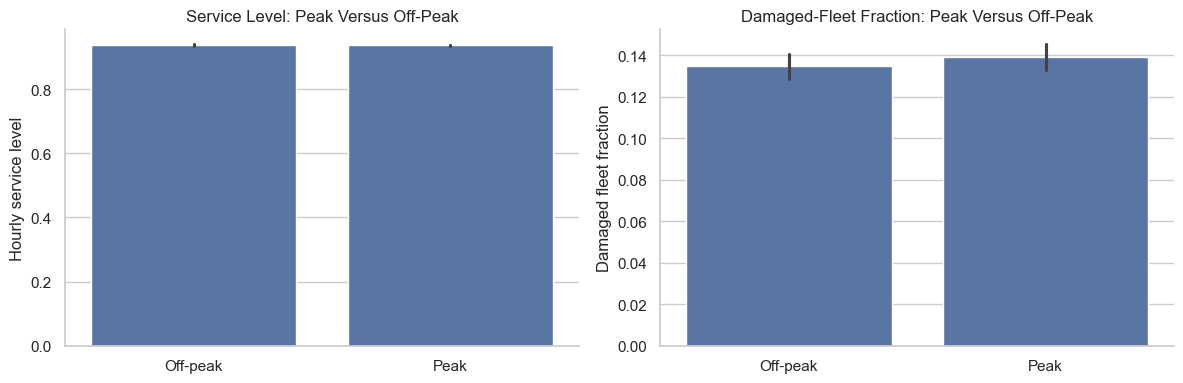

In [57]:
if not hourly.empty:
    temporal_summary = hourly.groupby(["period", "seed"], dropna=False).agg(
        service_level=("computed_service_level", "mean"),
        damaged_fraction=("damaged_fraction_total", "mean"),
        starvations=("starvations", "sum"),
        congestions=("congestions", "sum"),
        trips=("total_trips", "sum"),
    ).reset_index()
    display(temporal_summary.groupby("period").mean(numeric_only=True).round(4))

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.barplot(data=temporal_summary, x="period", y="service_level", errorbar="se", ax=axes[0])
    axes[0].set_title("Service Level: Peak Versus Off-Peak")
    axes[0].set_ylabel("Hourly service level")
    axes[0].set_xlabel("")

    sns.barplot(data=temporal_summary, x="period", y="damaged_fraction", errorbar="se", ax=axes[1])
    axes[1].set_title("Damaged-Fleet Fraction: Peak Versus Off-Peak")
    axes[1].set_ylabel("Damaged fleet fraction")
    axes[1].set_xlabel("")
    plt.tight_layout()
else:
    print("No hourly_metrics.csv files loaded.")

**Interpretation.** If maintenance shares are lower during peak periods without imposing explicit restrictions, the rollout policy appears to internalize the opportunity cost of maintenance during high-demand periods. If maintenance remains frequent during peaks while service level is stable, this supports full operational flexibility. If service level deteriorates during peaks while maintenance remains high, a peak-hour restriction is a plausible counterfactual to test.

## 3. Viability Thresholds for On-Site Repairs

**Managerial question.** When is on-site repair operationally worthwhile compared with transporting broken bikes to the depot?

The baseline run does not vary the repair-time parameter, so it cannot identify a causal break-even threshold. It can still show the realized balance between on-site repairs and depot collection under the chosen repair-time setting.

,seed,vehicle_role,onsite_repairs,depot_pickups,depot_returns,maintenance_decisions,total_active_decisions,onsite_share_of_repairs
0,42,integrated,437,450,65,892,4935,0.492672
1,43,integrated,429,426,63,845,4896,0.501754
2,44,integrated,449,452,66,896,4881,0.498335
3,45,integrated,469,411,63,869,4903,0.532955
4,46,integrated,444,440,64,855,5030,0.502262
5,47,integrated,401,452,66,854,4971,0.470106
6,48,integrated,426,464,64,873,4927,0.478652
7,49,integrated,429,458,63,883,4963,0.483653
8,50,integrated,457,456,64,885,5045,0.500548
9,51,integrated,494,461,64,927,4994,0.517277


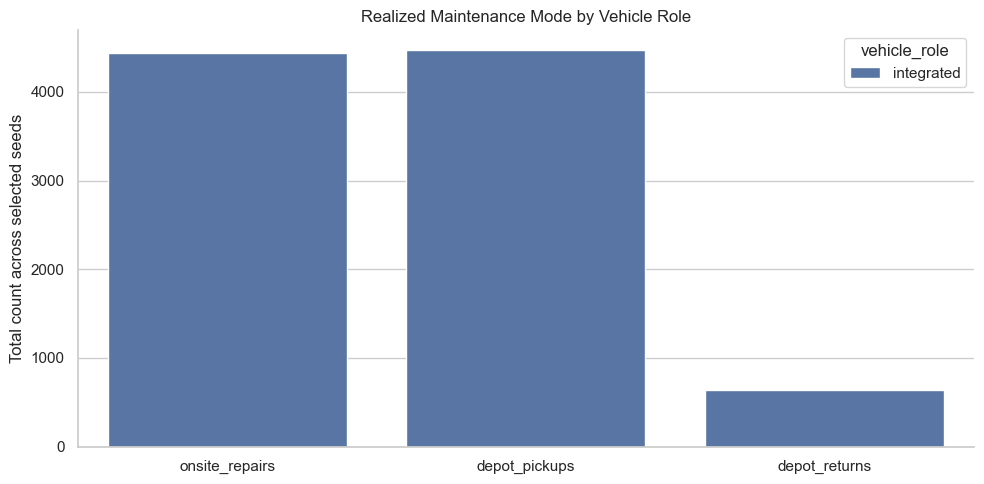

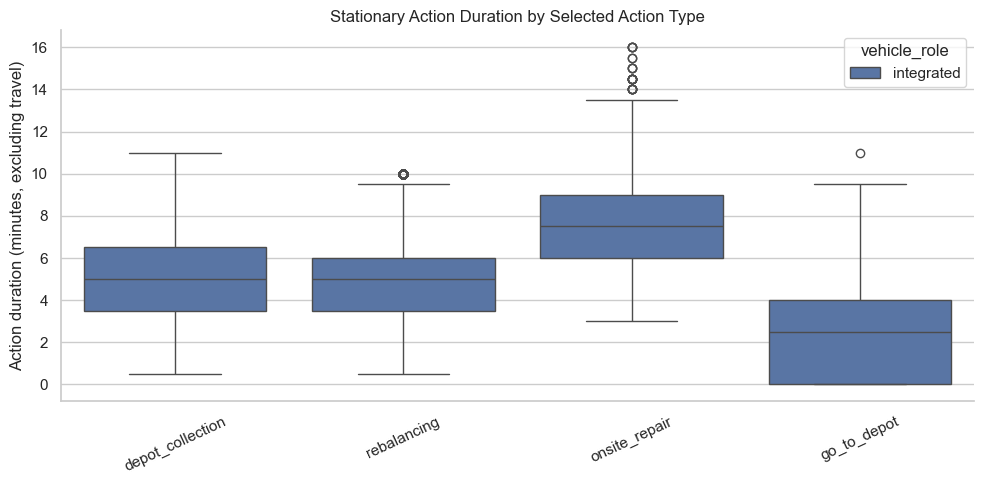

In [58]:
decision_data = active_decisions
if not decision_data.empty:
    repair_mode = decision_data.groupby(["seed", "vehicle_role"], dropna=False).agg(
        onsite_repairs=("onsite_repairs", "sum"),
        depot_pickups=("depot_pickups", "sum"),
        depot_returns=("depot_return_decision", "sum"),
        maintenance_decisions=("maintenance_action", "sum"),
        total_active_decisions=("derived_action_type", "size"),
    ).reset_index()
    repair_mode["onsite_share_of_repairs"] = repair_mode["onsite_repairs"] / (repair_mode["onsite_repairs"] + repair_mode["depot_pickups"]).replace(0, np.nan)
    display(repair_mode)

    mode_totals = repair_mode.groupby("vehicle_role", dropna=False)[["onsite_repairs", "depot_pickups", "depot_returns"]].sum().reset_index()
    mode_long = mode_totals.melt(id_vars="vehicle_role", var_name="mode", value_name="count")
    fig, ax = plt.subplots(figsize=(10, 5))
    sns.barplot(data=mode_long, x="mode", y="count", hue="vehicle_role", ax=ax)
    ax.set_title("Realized Maintenance Mode by Vehicle Role")
    ax.set_xlabel("")
    ax.set_ylabel("Total count across selected seeds")
    plt.tight_layout()

    duration_by_type = decision_data.loc[decision_data["derived_action_type"].isin(["onsite_repair", "depot_collection", "rebalancing", "mixed", "go_to_depot"])]
    if not duration_by_type.empty and "action_duration_min" in duration_by_type.columns:
        fig, ax = plt.subplots(figsize=(10, 5))
        sns.boxplot(data=duration_by_type, x="derived_action_type", y="action_duration_min", hue="vehicle_role", ax=ax)
        ax.set_title("Stationary Action Duration by Selected Action Type")
        ax.set_xlabel("")
        ax.set_ylabel("Action duration (minutes, excluding travel)")
        ax.tick_params(axis="x", rotation=25)
        plt.tight_layout()
else:
    print("No active decisions.csv rows loaded.")


**Interpretation.** The realized on-site repair share describes whether the integrated policy considered immediate repair attractive under the current repair-time assumption. A break-even rule such as “perform on-site repairs only below X minutes” requires additional runs with different `tau_rep` values while keeping all other parameters fixed.

**Additional experiment.** Run the same trained or retrained policy for `tau_rep_values = [1, 3, 5, 7, 10, 15]`, log `repair_time`, and compare service level, on-site repairs, depot pickups, and vehicle time spent stationary.

## 4. Optimal Balance Between Maintenance and Rebalancing

**Managerial question.** Does the policy behave like a fixed maintenance/rebalancing split, or does it dynamically shift effort with system conditions?

The baseline run can address this by relating daily and hourly action composition to service level, demand volume, and damaged-bike state.

,seed,day,daily_service_level,maintenance_share,rebalancing_share,eod_damaged_fraction_total
0,42,6,0.970588,NaN,NaN,0.0212
1,42,7,0.935247,0.173554,0.888430,0.0237
2,42,8,0.943299,0.180672,0.861345,0.0277
3,42,9,0.955993,0.213043,0.865217,0.0324
4,42,10,0.957831,0.176230,0.860656,0.0383


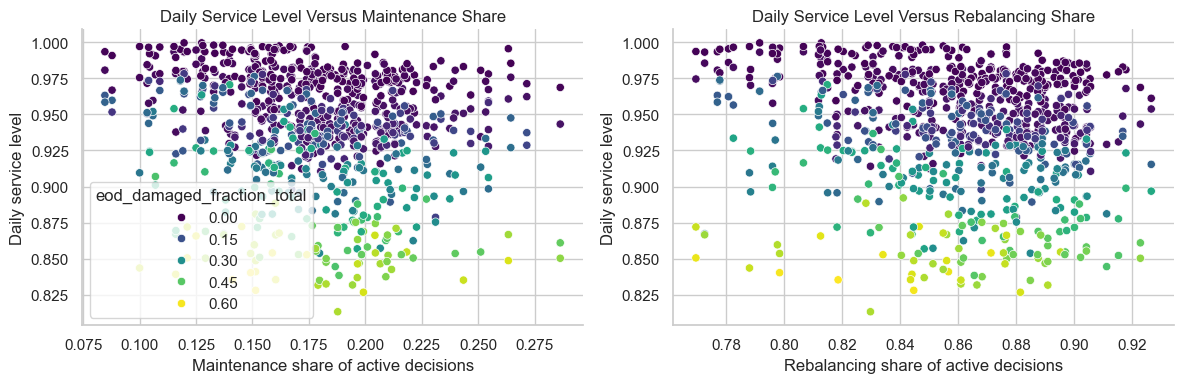

In [59]:
decision_data = active_decisions
if not decision_data.empty and not daily.empty:
    daily_actions = decision_data.groupby(["seed", "day"], dropna=False).agg(
        maintenance_share=("maintenance_action", "mean"),
        rebalancing_share=("rebalancing_action", "mean"),
        mixed_share=("mixed_action", "mean"),
        onsite_repairs=("onsite_repairs", "sum"),
        depot_pickups=("depot_pickups", "sum"),
        functional_pickups=("functional_pickups", "sum"),
        functional_deliveries=("functional_deliveries", "sum"),
    ).reset_index()
    daily_joined = daily.merge(daily_actions, on=["seed", "day"], how="left")
    display(daily_joined[["seed", "day", "daily_service_level", "maintenance_share", "rebalancing_share", "eod_damaged_fraction_total"]].head())

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.scatterplot(data=daily_joined, x="maintenance_share", y="daily_service_level", hue="eod_damaged_fraction_total", palette="viridis", ax=axes[0])
    axes[0].set_title("Daily Service Level Versus Maintenance Share")
    axes[0].set_xlabel("Maintenance share of active decisions")
    axes[0].set_ylabel("Daily service level")

    sns.scatterplot(data=daily_joined, x="rebalancing_share", y="daily_service_level", hue="eod_damaged_fraction_total", palette="viridis", ax=axes[1], legend=False)
    axes[1].set_title("Daily Service Level Versus Rebalancing Share")
    axes[1].set_xlabel("Rebalancing share of active decisions")
    axes[1].set_ylabel("Daily service level")
    plt.tight_layout()
else:
    show_required("both daily_metrics.csv and active decisions.csv rows to relate daily action composition to daily service outcomes.")


,seed,maintenance_share,rebalancing_share,service_level
demand_level,,,,
Low,46.5,0.1796,0.8038,0.9490
Medium,46.5,0.1838,0.9087,0.9437
High,46.5,0.1822,0.8980,0.9328


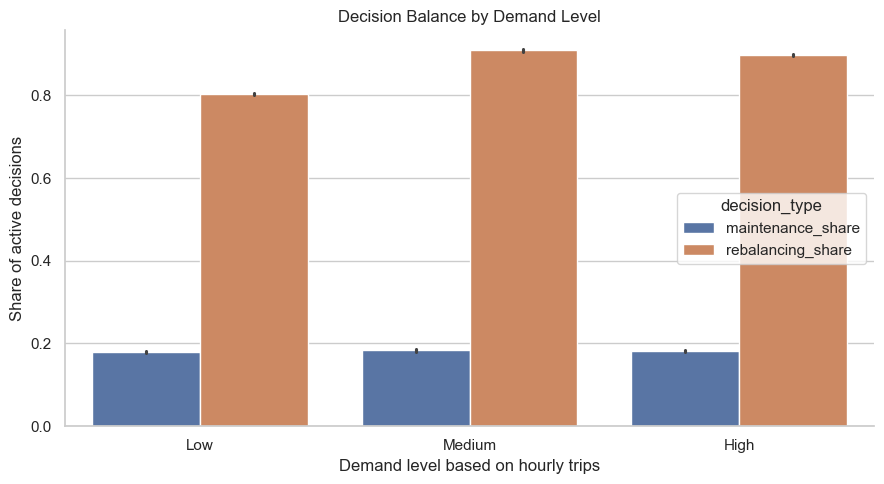

In [60]:
decision_data = active_decisions
if not decision_data.empty and not hourly.empty:
    hourly_demand = hourly.groupby(["seed", "day", "hour"], dropna=False).agg(
        trips=("total_trips", "sum"),
        service_level=("computed_service_level", "mean"),
        damaged_fraction=("damaged_fraction_total", "mean"),
    ).reset_index()
    hourly_actions = decision_data.groupby(["seed", "day", "hour"], dropna=False).agg(
        maintenance_share=("maintenance_action", "mean"),
        rebalancing_share=("rebalancing_action", "mean"),
        n_active_decisions=("derived_action_type", "size"),
    ).reset_index()
    hourly_joined = hourly_demand.merge(hourly_actions, on=["seed", "day", "hour"], how="left")
    hourly_joined = hourly_joined.dropna(subset=["trips", "maintenance_share"])
    hourly_joined["demand_level"] = pd.qcut(hourly_joined["trips"].rank(method="first"), q=3, labels=["Low", "Medium", "High"])

    demand_mix = hourly_joined.groupby(["demand_level", "seed"], observed=False).agg(
        maintenance_share=("maintenance_share", "mean"),
        rebalancing_share=("rebalancing_share", "mean"),
        service_level=("service_level", "mean"),
    ).reset_index()
    display(demand_mix.groupby("demand_level", observed=False).mean(numeric_only=True).round(4))

    fig, ax = plt.subplots()
    long = demand_mix.melt(id_vars=["demand_level", "seed"], value_vars=["maintenance_share", "rebalancing_share"], var_name="decision_type", value_name="share")
    sns.barplot(data=long, x="demand_level", y="share", hue="decision_type", errorbar="se", ax=ax)
    ax.set_title("Decision Balance by Demand Level")
    ax.set_xlabel("Demand level based on hourly trips")
    ax.set_ylabel("Share of active decisions")
    plt.tight_layout()
else:
    show_required("hourly demand and active decision logs to analyze dynamic action balance.")


**Interpretation.** If the maintenance share changes with demand level, hour, or damaged-fleet state, a fixed operational split is unlikely to be sufficient. A dynamic policy is especially valuable when high maintenance effort appears on days or hours with elevated damaged-bike pressure rather than uniformly across the horizon.

## 5. Marginal Benefit of Increased Service Vehicle Capacity

**Managerial question.** Would additional service vehicles materially improve performance?

For the selected scenario, the notebook reports vehicle-level utilization and action allocation. Once runs such as `S1_integrated_vfa_1` and `S2_integrated_vfa_2` are added to `OPTIONAL_COMPARISON_RUN_DIRS`, the comparison section estimates the marginal service-level improvement from adding the second vehicle.

,count,mean,std,min,25%,50%,75%,max
operation_minutes,560.0,673.911,446.148,0.0,445.750,752.750,1070.000,1315.00
travel_minutes,560.0,875.684,579.168,0.0,427.700,811.485,1427.038,1646.07
vehicle_time_minutes,560.0,1549.594,1011.969,0.0,891.218,1554.835,2512.095,2612.08
active_minutes_proxy,560.0,1549.594,1011.969,0.0,891.218,1554.835,2512.095,2612.08
maintenance_actions,560.0,15.677,19.950,0.0,0.000,4.000,31.000,87.00
rebalancing_actions,560.0,76.082,84.542,0.0,0.000,29.500,122.250,228.00


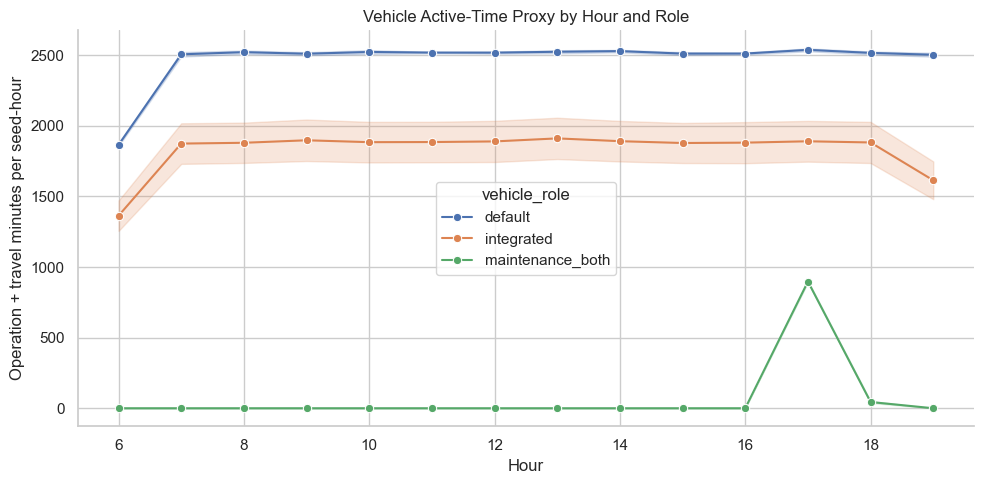

In [61]:
if not decisions.empty:
    utilization_hour = decisions.groupby(["seed", "vehicle_id", "vehicle_role", "hour"], dropna=False).agg(
        decision_rows=("derived_action_type", "size"),
        active_decisions=("vehicle_active_bool", "sum"),
        operation_minutes=("action_duration_min", "sum"),
        travel_minutes=("travel_time_min", "sum"),
        vehicle_time_minutes=("vehicle_time_min", "sum"),
        maintenance_actions=("maintenance_action", "sum"),
        rebalancing_actions=("rebalancing_action", "sum"),
    ).reset_index()
    utilization_hour["active_minutes_proxy"] = utilization_hour["vehicle_time_minutes"].fillna(utilization_hour["operation_minutes"].fillna(0) + utilization_hour["travel_minutes"].fillna(0))

    fig, ax = plt.subplots(figsize=(10, 5))
    sns.lineplot(data=utilization_hour, x="hour", y="active_minutes_proxy", hue="vehicle_role", estimator="mean", errorbar="se", marker="o", ax=ax)
    ax.set_title("Vehicle Active-Time Proxy by Hour and Role")
    ax.set_xlabel("Hour")
    ax.set_ylabel("Operation + travel minutes per seed-hour")
    plt.tight_layout()

    display(utilization_hour[["operation_minutes", "travel_minutes", "vehicle_time_minutes", "active_minutes_proxy", "maintenance_actions", "rebalancing_actions"]].describe().T.round(3))
else:
    print("No decisions.csv files loaded.")


**Interpretation.** High active-time proxy during many hours suggests that the single vehicle is a potential capacity bottleneck. This is only indirect evidence. A true marginal benefit curve requires runs with `num_service_vehicles_values = [1, 2, 3, 4]` under the same demand, maintenance, and VFA settings.

**Additional experiment.** For each vehicle count, log service level, hourly failures, action composition, vehicle-level active/idle/travel/repair time, and damaged-bike accumulation.

## 6. Depot Strategy and Optimal Vehicle Filling Level

**Managerial question.** Does the policy wait until the vehicle is full of broken bikes before returning to the depot, or does it return earlier when operationally useful?

The decision log can answer this directly by examining the broken-bike load when the selected next station is the depot.

,seed,vehicle_role,depot_returns,avg_broken_load,avg_load_utilization,median_load_utilization
0,42,integrated,65,6.923077,0.346154,0.300
1,43,integrated,63,6.761905,0.338095,0.300
2,44,integrated,66,6.848485,0.342424,0.350
3,45,integrated,63,6.523810,0.326190,0.300
4,46,integrated,64,6.875000,0.343750,0.300
5,47,integrated,66,6.848485,0.342424,0.350
6,48,integrated,64,7.250000,0.362500,0.325
7,49,integrated,63,7.269841,0.363492,0.350
8,50,integrated,64,7.125000,0.356250,0.350
9,51,integrated,64,7.203125,0.360156,0.350


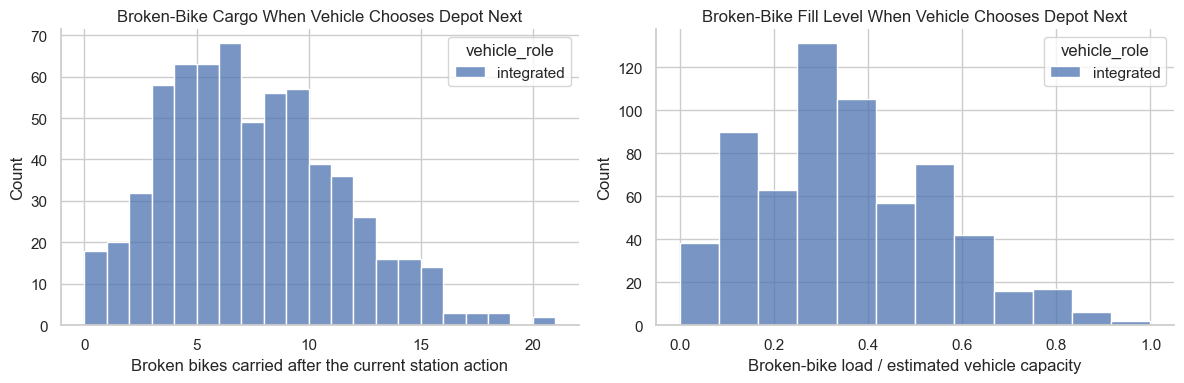

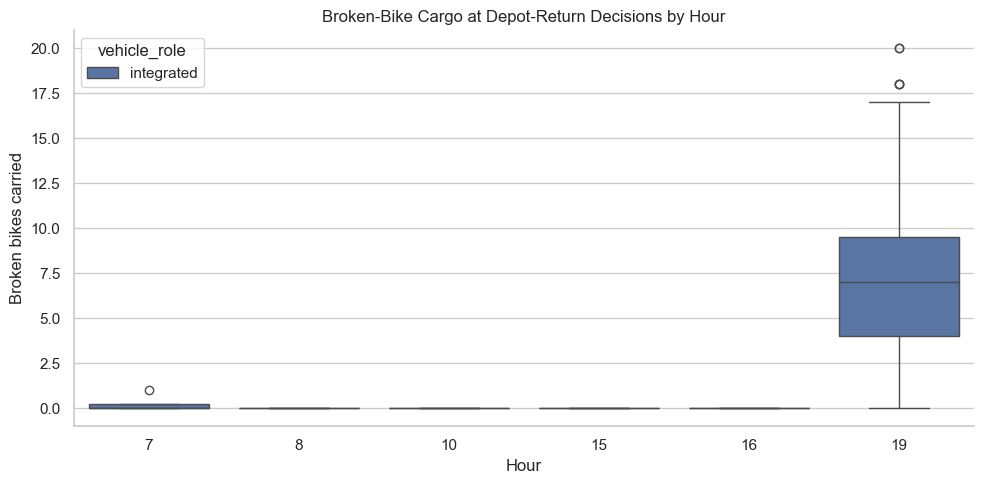

In [62]:
decision_data = active_decisions
if not decision_data.empty:
    depot_returns = decision_data[decision_data["depot_return_decision"]].copy()
    if not depot_returns.empty:
        depot_summary = depot_returns.groupby(["seed", "vehicle_role"], dropna=False).agg(
            depot_returns=("depot_return_decision", "sum"),
            avg_broken_load=("broken_load_to_depot", "mean"),
            avg_load_utilization=("broken_load_utilization_to_depot", "mean"),
            median_load_utilization=("broken_load_utilization_to_depot", "median"),
        ).reset_index()
        display(depot_summary)

        fig, axes = plt.subplots(1, 2, figsize=(12, 4))
        max_capacity = depot_returns["estimated_vehicle_capacity"].dropna().max()
        bins = range(0, int(max_capacity) + 2) if pd.notna(max_capacity) and max_capacity > 0 else 12
        sns.histplot(data=depot_returns, x="broken_load_to_depot", hue="vehicle_role", multiple="stack", bins=bins, ax=axes[0])
        axes[0].set_title("Broken-Bike Cargo When Vehicle Chooses Depot Next")
        axes[0].set_xlabel("Broken bikes carried after the current station action")

        sns.histplot(data=depot_returns, x="broken_load_utilization_to_depot", hue="vehicle_role", multiple="stack", bins=12, ax=axes[1])
        axes[1].set_title("Broken-Bike Fill Level When Vehicle Chooses Depot Next")
        axes[1].set_xlabel("Broken-bike load / estimated vehicle capacity")
        plt.tight_layout()

        fig, ax = plt.subplots(figsize=(10, 5))
        sns.boxplot(data=depot_returns, x="hour", y="broken_load_to_depot", hue="vehicle_role", ax=ax)
        ax.set_title("Broken-Bike Cargo at Depot-Return Decisions by Hour")
        ax.set_xlabel("Hour")
        ax.set_ylabel("Broken bikes carried")
        plt.tight_layout()
    else:
        print("No active decisions where the selected next station is a depot were found.")
else:
    print("No active decisions.csv rows loaded.")


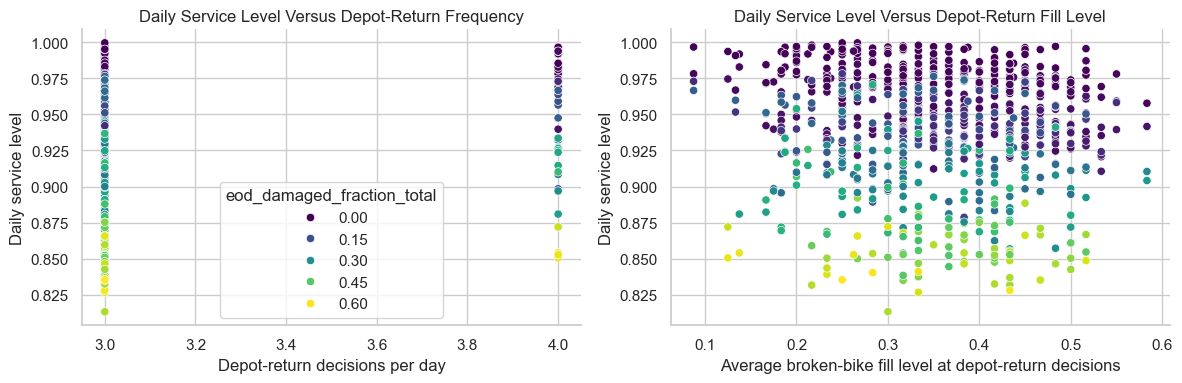

In [63]:
# Relate depot-return behavior to daily outcomes.
decision_data = active_decisions
if not decision_data.empty and not daily.empty:
    depot_daily = decision_data.groupby(["seed", "day"], dropna=False).agg(
        depot_returns=("depot_return_decision", "sum"),
        avg_depot_return_load=("broken_load_to_depot", "mean"),
        avg_depot_return_utilization=("broken_load_utilization_to_depot", "mean"),
    ).reset_index()
    depot_daily = daily.merge(depot_daily, on=["seed", "day"], how="left")

    fig, axes = plt.subplots(1, 2, figsize=(12, 4))
    sns.scatterplot(data=depot_daily, x="depot_returns", y="daily_service_level", hue="eod_damaged_fraction_total", palette="viridis", ax=axes[0])
    axes[0].set_title("Daily Service Level Versus Depot-Return Frequency")
    axes[0].set_xlabel("Depot-return decisions per day")
    axes[0].set_ylabel("Daily service level")

    sns.scatterplot(data=depot_daily, x="avg_depot_return_utilization", y="daily_service_level", hue="eod_damaged_fraction_total", palette="viridis", ax=axes[1], legend=False)
    axes[1].set_title("Daily Service Level Versus Depot-Return Fill Level")
    axes[1].set_xlabel("Average broken-bike fill level at depot-return decisions")
    axes[1].set_ylabel("Daily service level")
    plt.tight_layout()
else:
    show_required("daily metrics and active decision-level depot-return load to relate depot behavior to outcomes.")


**Interpretation.** If depot returns often occur below full capacity, the policy is not simply following a fill-the-vehicle rule. Early returns may be rational when remaining shift time, route position, or depot repair queues make unloading valuable. A threshold policy should only be recommended if a counterfactual threshold experiment performs similarly to the flexible rollout policy.

## Cross-Scenario Comparison

Use this section after generating additional scenarios or alternative configurations. The plots use `contrast_label` rather than folder names, so the visual comparison is explicit. Edit `CONTRAST_LABELS` in the configuration cell to name each operational strategy in thesis-friendly language.


,contrast_label,policy_label,scenario_name,seeds,service_level_mean,service_level_std,starvations,congestions,broken_end_onsite,broken_end_depot,num_service_vehicles
0,"Integrated VFA, 1 vehicle","Integrated VFA, 1 vehicle | run_20260515_165207",S1_integrated_vfa_1,10,0.9497,0.0031,2116.2,879.1,3.7,16.7,1.0
1,"Integrated VFA, 2 vehicles","Integrated VFA, 2 vehicles | run_20260515_165249",S2_integrated_vfa_2,10,0.9775,0.0016,1025.5,316.3,1.1,8.7,2.0
3,Separated: day rebalance + maintenance window,Separated: day rebalance + maintenance window ...,S3_day_rebalance_day_maintenance,10,0.9188,0.0105,3602.6,1234.5,127.6,157.7,2.0
2,Separated: day rebalance + after-hours mainten...,Separated: day rebalance + after-hours mainten...,S4_day_rebalance_after_hours,10,0.9037,0.0073,4627.9,1111.1,210.9,229.4,2.0


,contrast_label,policy_label,scenario_name,active_decisions,maintenance_actions,rebalancing_actions,depot_returns,maintenance_share,rebalancing_share,depot_return_share
0,"Integrated VFA, 1 vehicle","Integrated VFA, 1 vehicle | run_20260515_165207",S1_integrated_vfa_1,15333,3896,13579,210,0.2541,0.8856,0.0137
1,"Integrated VFA, 2 vehicles","Integrated VFA, 2 vehicles | run_20260515_165249",S2_integrated_vfa_2,34212,4883,29027,432,0.1427,0.8484,0.0126


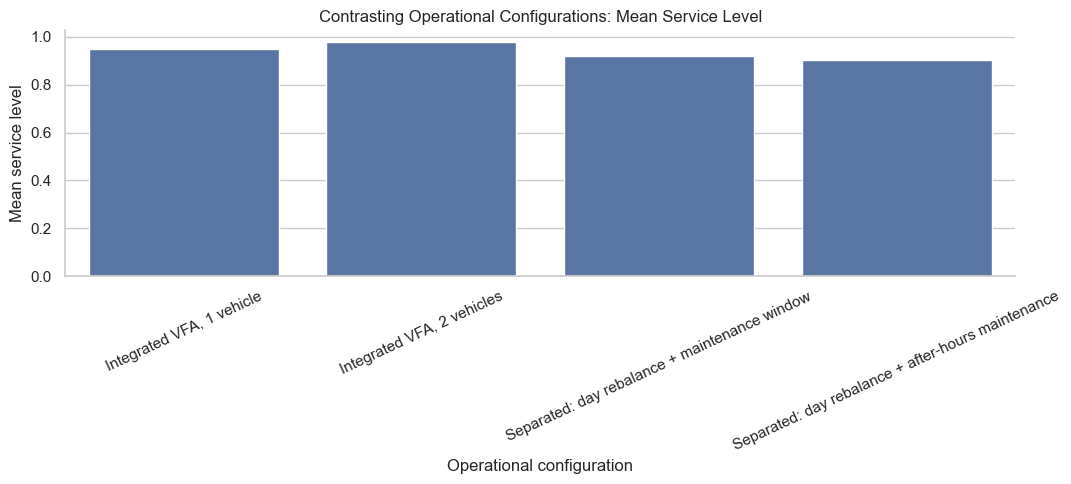

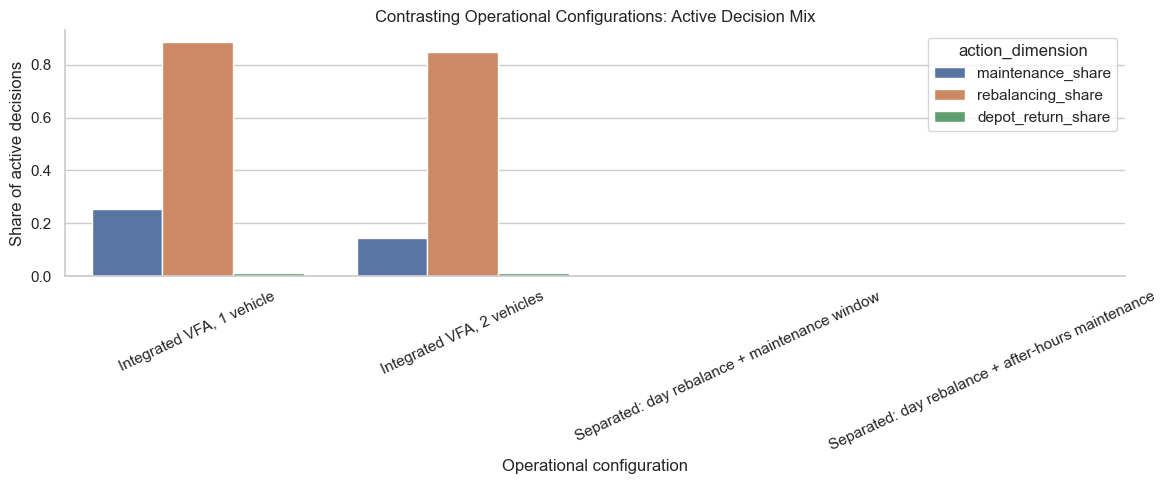

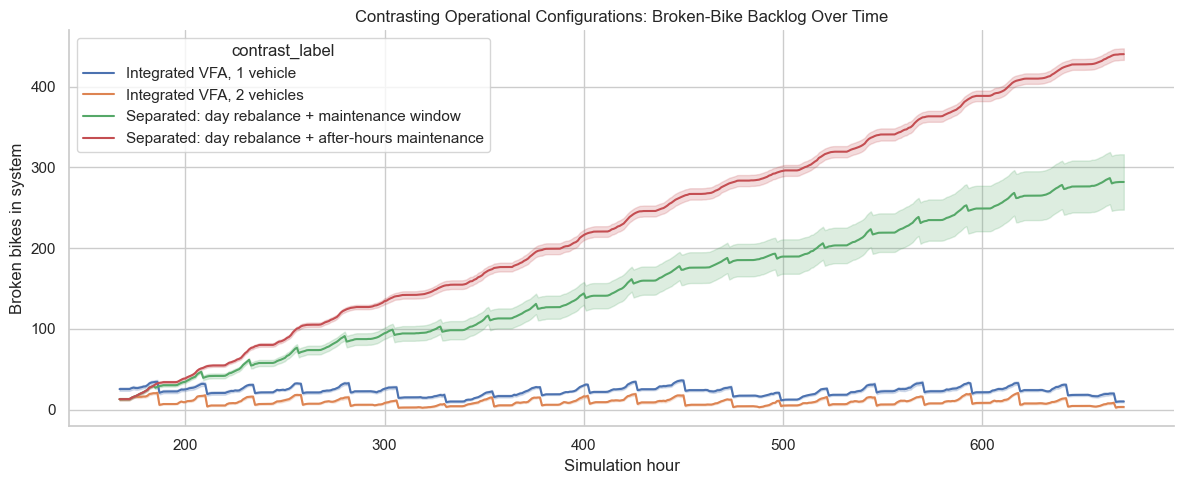

In [64]:
# Compare all loaded scenarios and optional comparison folders.
if not results_all.empty or not daily_all.empty:
    group_keys = ["contrast_label", "policy_label", "scenario_name"]
    if not results_all.empty and "service_level" in results_all.columns:
        comparison_summary = results_all.groupby(group_keys, dropna=False).agg(
            seeds=("seed", "nunique"),
            service_level_mean=("service_level", "mean"),
            service_level_std=("service_level", "std"),
            starvations=("starvations", "mean"),
            congestions=("congestions", "mean"),
            broken_end_onsite=("broken_bikes_end_onsite", "mean"),
            broken_end_depot=("broken_bikes_end_depot", "mean"),
            num_service_vehicles=("num_service_vehicles", "mean"),
        ).reset_index()
    else:
        comparison_summary = daily_all.groupby(group_keys + ["seed"], dropna=False).agg(
            service_level=("daily_service_level", "mean"),
            starvations=("daily_starvations", "sum"),
            congestions=("daily_congestions", "sum"),
        ).reset_index().groupby(group_keys, dropna=False).agg(
            seeds=("seed", "nunique"),
            service_level_mean=("service_level", "mean"),
            service_level_std=("service_level", "std"),
            starvations=("starvations", "mean"),
            congestions=("congestions", "mean"),
        ).reset_index()

    contrast_order = ordered_labels(comparison_summary["contrast_label"])
    comparison_summary["contrast_label"] = pd.Categorical(comparison_summary["contrast_label"], categories=contrast_order, ordered=True)
    comparison_summary = comparison_summary.sort_values("contrast_label")
    display(comparison_summary.round(4))

    fig, ax = plt.subplots(figsize=(11, 5))
    sns.barplot(data=comparison_summary, x="contrast_label", y="service_level_mean", order=contrast_order, errorbar=None, ax=ax)
    ax.set_title("Contrasting Operational Configurations: Mean Service Level")
    ax.set_xlabel("Operational configuration")
    ax.set_ylabel("Mean service level")
    ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()

    if not active_decisions_all.empty:
        action_summary = active_decisions_all.groupby(["contrast_label", "policy_label", "scenario_name"], dropna=False).agg(
            active_decisions=("derived_action_type", "size"),
            maintenance_actions=("maintenance_action", "sum"),
            rebalancing_actions=("rebalancing_action", "sum"),
            depot_returns=("depot_return_decision", "sum"),
        ).reset_index()
        action_summary["maintenance_share"] = action_summary["maintenance_actions"] / action_summary["active_decisions"].replace(0, np.nan)
        action_summary["rebalancing_share"] = action_summary["rebalancing_actions"] / action_summary["active_decisions"].replace(0, np.nan)
        action_summary["depot_return_share"] = action_summary["depot_returns"] / action_summary["active_decisions"].replace(0, np.nan)
        action_summary["contrast_label"] = pd.Categorical(action_summary["contrast_label"], categories=contrast_order, ordered=True)
        action_summary = action_summary.sort_values("contrast_label")
        display(action_summary.round(4))

        action_long = action_summary.melt(
            id_vars=["contrast_label", "policy_label", "scenario_name"],
            value_vars=["maintenance_share", "rebalancing_share", "depot_return_share"],
            var_name="action_dimension",
            value_name="share",
        )
        fig, ax = plt.subplots(figsize=(12, 5))
        sns.barplot(data=action_long, x="contrast_label", y="share", hue="action_dimension", order=contrast_order, ax=ax)
        ax.set_title("Contrasting Operational Configurations: Active Decision Mix")
        ax.set_xlabel("Operational configuration")
        ax.set_ylabel("Share of active decisions")
        ax.tick_params(axis="x", rotation=25)
        plt.tight_layout()

    if not hourly_all.empty and "broken_bikes_total" in hourly_all.columns:
        hourly_plot = hourly_all.copy()
        hourly_plot["contrast_label"] = pd.Categorical(hourly_plot["contrast_label"], categories=contrast_order, ordered=True)
        fig, ax = plt.subplots(figsize=(12, 5))
        sns.lineplot(data=hourly_plot, x="absolute_hour", y="broken_bikes_total", hue="contrast_label", estimator="mean", errorbar="se", ax=ax)
        ax.set_title("Contrasting Operational Configurations: Broken-Bike Backlog Over Time")
        ax.set_xlabel("Simulation hour")
        ax.set_ylabel("Broken bikes in system")
        plt.tight_layout()
else:
    print("No loaded results or daily metrics available. Add run folders to SCENARIO_RUN_DIRS or OPTIONAL_COMPARISON_RUN_DIRS.")


## Timing of Maintenance and Rebalancing by Strategy

This section shows, for each coordination strategy, when active decisions are allocated to rebalancing and maintenance. The categories are mutually exclusive: pure rebalancing, pure maintenance, mixed rebalancing and maintenance, and other active decisions. A separate summary reports the number of bikes repaired or restored in each strategy.

action_mix_category,Pure rebalancing,Pure maintenance,Mixed rebalancing + maintenance,Other active decision
contrast_label,,,,
"Integrated VFA, 1 vehicle",0.6901,0.0579,0.2019,0.0563
"Integrated VFA, 2 vehicles",0.7507,0.0426,0.1035,0.1042


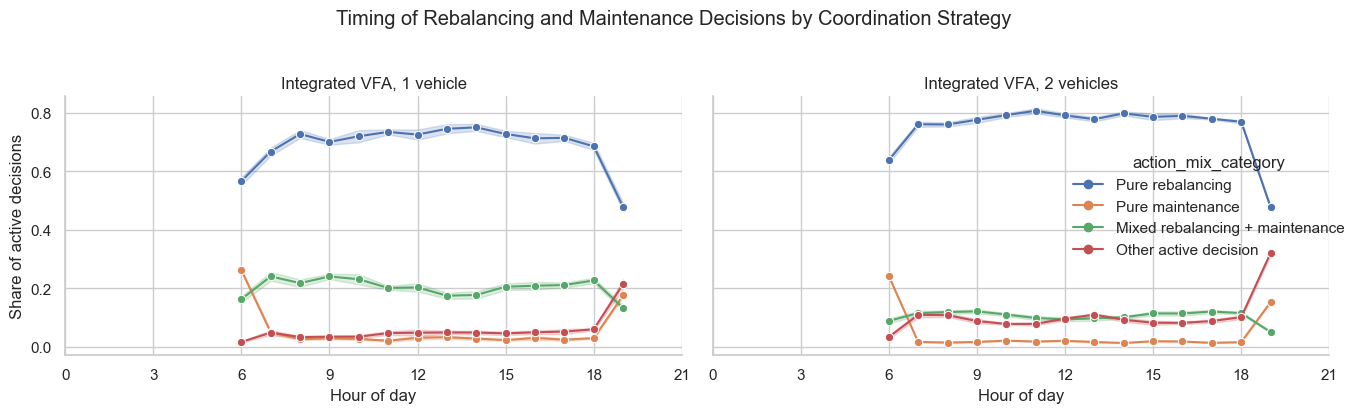

In [65]:
# One timing plot per coordination strategy: when does the policy rebalance and maintain?
if not active_decisions_all.empty:
    timing_data = active_decisions_all.copy()
    if "action_mix_category" not in timing_data.columns:
        timing_data["action_mix_category"] = np.select(
            [
                timing_data["maintenance_action"] & timing_data["rebalancing_action"],
                timing_data["maintenance_action"] & ~timing_data["rebalancing_action"],
                ~timing_data["maintenance_action"] & timing_data["rebalancing_action"],
            ],
            [
                "Mixed rebalancing + maintenance",
                "Pure maintenance",
                "Pure rebalancing",
            ],
            default="Other active decision",
        )

    contrast_order = ordered_labels(timing_data["contrast_label"])
    category_order = [
        "Pure rebalancing",
        "Pure maintenance",
        "Mixed rebalancing + maintenance",
        "Other active decision",
    ]

    hourly_mix = timing_data.groupby(["contrast_label", "seed", "hour", "action_mix_category"], dropna=False).size().reset_index(name="count")
    hourly_total = timing_data.groupby(["contrast_label", "seed", "hour"], dropna=False).size().reset_index(name="total_active_decisions")
    hourly_mix = hourly_mix.merge(hourly_total, on=["contrast_label", "seed", "hour"], how="left")
    hourly_mix["share"] = hourly_mix["count"] / hourly_mix["total_active_decisions"].replace(0, np.nan)
    hourly_mix["contrast_label"] = pd.Categorical(hourly_mix["contrast_label"], categories=contrast_order, ordered=True)
    hourly_mix["action_mix_category"] = pd.Categorical(hourly_mix["action_mix_category"], categories=category_order, ordered=True)

    g = sns.relplot(
        data=hourly_mix,
        x="hour",
        y="share",
        hue="action_mix_category",
        col="contrast_label",
        col_wrap=2,
        kind="line",
        marker="o",
        estimator="mean",
        errorbar="se",
        facet_kws={"sharey": True, "sharex": True},
        height=4,
        aspect=1.35,
    )
    g.set_titles("{col_name}")
    g.set_axis_labels("Hour of day", "Share of active decisions")
    g.fig.suptitle("Timing of Rebalancing and Maintenance Decisions by Coordination Strategy", y=1.03)
    for ax in g.axes.flatten():
        ax.set_xticks(range(0, 24, 3))
    plt.tight_layout()

    display(hourly_mix.groupby(["contrast_label", "action_mix_category"], observed=False)["share"].mean().reset_index().pivot(
        index="contrast_label", columns="action_mix_category", values="share"
    ).round(4))
else:
    print("No active decision logs loaded.")


,contrast_label,scenario_name,seeds,onsite_repairs_mean,onsite_repairs_std,depot_repairs_mean,depot_repairs_std,bikes_collected_for_depot_mean,total_repaired_or_restored_mean,total_repaired_or_restored_std
0,"Integrated VFA, 1 vehicle",S1_integrated_vfa_1,10,218.2,8.561,226.9,13.262,225.0,445.1,18.015
1,"Integrated VFA, 2 vehicles",S2_integrated_vfa_2,10,225.3,19.397,223.8,10.174,222.0,449.1,21.901
3,Separated: day rebalance + maintenance window,S3_day_rebalance_day_maintenance,10,91.2,54.988,74.1,56.771,73.3,165.3,108.701
2,Separated: day rebalance + after-hours mainten...,S4_day_rebalance_after_hours,10,0.0,0.000,8.6,5.461,0.0,8.6,5.461


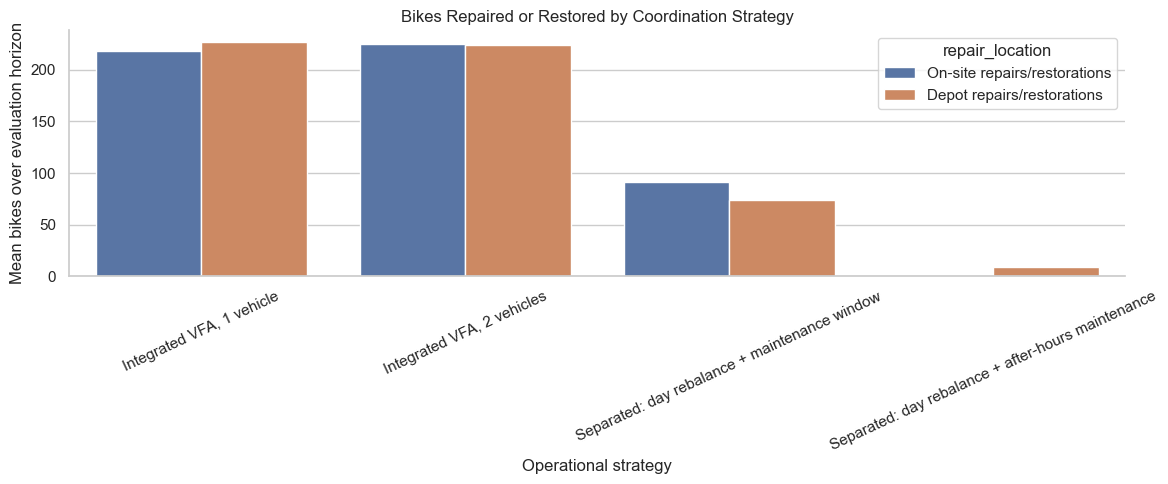

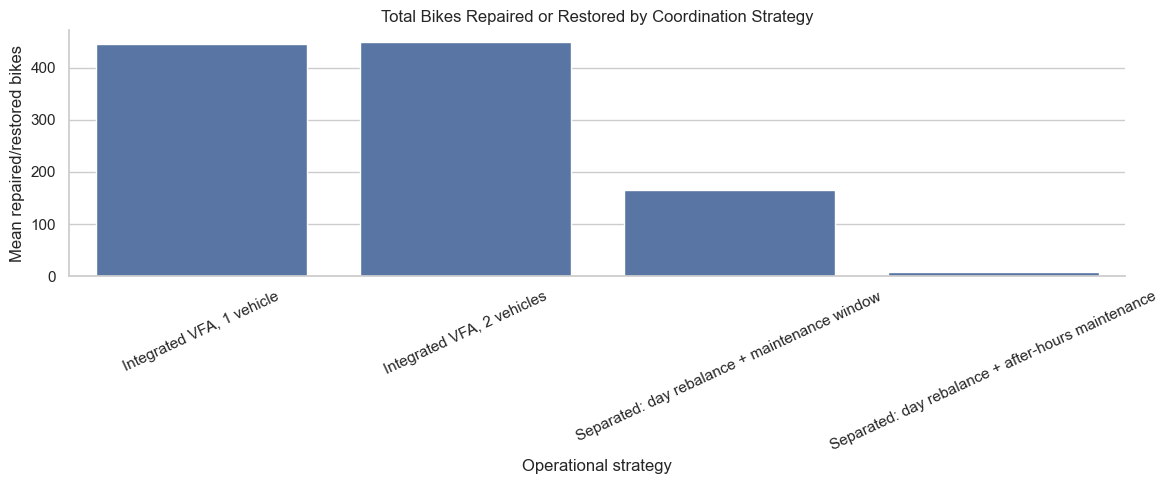

In [66]:
# Repaired/restored bikes by coordination strategy.
# Decision-level onsite_repairs counts immediate on-site repairs. Depot restoration is best read
# from results.csv/daily_metrics.csv when available, because depot repair completion may happen
# outside the exact vehicle decision that collected the bike.
repair_frames = []

if not results_all.empty:
    result_cols = [c for c in [
        "contrast_label", "scenario_name", "seed",
        "total_fixed_on_site", "total_depot_fixes", "restored_onsite", "restored_depot",
        "total_picked_up_to_depot", "total_depot_deliveries",
    ] if c in results_all.columns]
    result_repairs = results_all[result_cols].copy()
    for col in ["total_fixed_on_site", "total_depot_fixes", "restored_onsite", "restored_depot", "total_picked_up_to_depot", "total_depot_deliveries"]:
        if col not in result_repairs.columns:
            result_repairs[col] = 0
        result_repairs[col] = pd.to_numeric(result_repairs[col], errors="coerce").fillna(0)

    result_repairs["onsite_repairs_or_restorations"] = result_repairs[["total_fixed_on_site", "restored_onsite"]].max(axis=1)
    result_repairs["depot_repairs_or_restorations"] = result_repairs[["total_depot_fixes", "restored_depot", "total_depot_deliveries"]].max(axis=1)
    result_repairs["bikes_collected_for_depot"] = result_repairs["total_picked_up_to_depot"]
    result_repairs["total_repaired_or_restored"] = result_repairs["onsite_repairs_or_restorations"] + result_repairs["depot_repairs_or_restorations"]
    repair_frames.append(result_repairs)

if repair_frames:
    repair_by_seed = pd.concat(repair_frames, ignore_index=True, sort=False)
    repair_summary = repair_by_seed.groupby(["contrast_label", "scenario_name"], dropna=False).agg(
        seeds=("seed", "nunique"),
        onsite_repairs_mean=("onsite_repairs_or_restorations", "mean"),
        onsite_repairs_std=("onsite_repairs_or_restorations", "std"),
        depot_repairs_mean=("depot_repairs_or_restorations", "mean"),
        depot_repairs_std=("depot_repairs_or_restorations", "std"),
        bikes_collected_for_depot_mean=("bikes_collected_for_depot", "mean"),
        total_repaired_or_restored_mean=("total_repaired_or_restored", "mean"),
        total_repaired_or_restored_std=("total_repaired_or_restored", "std"),
    ).reset_index()

    contrast_order = ordered_labels(repair_summary["contrast_label"])
    repair_summary["contrast_label"] = pd.Categorical(repair_summary["contrast_label"], categories=contrast_order, ordered=True)
    repair_summary = repair_summary.sort_values("contrast_label")
    display(repair_summary.round(3))

    repair_long = repair_summary.melt(
        id_vars=["contrast_label", "scenario_name"],
        value_vars=["onsite_repairs_mean", "depot_repairs_mean"],
        var_name="repair_location",
        value_name="mean_bikes",
    )
    repair_long["repair_location"] = repair_long["repair_location"].map({
        "onsite_repairs_mean": "On-site repairs/restorations",
        "depot_repairs_mean": "Depot repairs/restorations",
    })

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=repair_long, x="contrast_label", y="mean_bikes", hue="repair_location", order=contrast_order, ax=ax)
    ax.set_title("Bikes Repaired or Restored by Coordination Strategy")
    ax.set_xlabel("Operational strategy")
    ax.set_ylabel("Mean bikes over evaluation horizon")
    ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()

    fig, ax = plt.subplots(figsize=(12, 5))
    sns.barplot(data=repair_summary, x="contrast_label", y="total_repaired_or_restored_mean", order=contrast_order, ax=ax)
    ax.set_title("Total Bikes Repaired or Restored by Coordination Strategy")
    ax.set_xlabel("Operational strategy")
    ax.set_ylabel("Mean repaired/restored bikes")
    ax.tick_params(axis="x", rotation=25)
    plt.tight_layout()
else:
    show_required("results.csv columns such as total_fixed_on_site, restored_onsite, restored_depot, or total_depot_fixes to summarize repaired bikes.")


## Recommended Result Schema Additions

The current run already supports many behavioral insights. The following additions would make the managerial chapter stronger and reduce path-based inference:

- `run_id` in every CSV file.
- `policy_name`, `restriction_type`, and `restriction_active` in `decisions.csv`.
- `vehicle_id` in `decisions.csv`, plus active, idle, travel, repair, and depot time by vehicle.
- `go_to_depot` as a selected-routing flag, in addition to `next_station_id`.
- `vehicle_capacity` explicitly logged at each decision.
- `repair_time` and `num_service_vehicles` explicitly logged in `results.csv`.
- Candidate diagnostics: number of maintenance candidates available, number removed by restrictions, and whether the restriction changed the selected action.